In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sqlite3
import warnings
from typing import Dict, List, Optional, Tuple
warnings.filterwarnings('ignore')

# Configure matplotlib for publication-quality output
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.titlesize': 14,
    'figure.dpi': 100,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'axes.axisbelow': True,
})

# Define color scheme for consistency
COLORS = {
    'cpu': '#E74C3C',           # Red
    'gpu_kernel': '#3498DB',    # Blue
    'gpu_memory': '#9B59B6',    # Purple
    'mpi': '#F39C12',           # Orange
    'naive': '#95A5A6',         # Gray
    'optimized': '#27AE60',     # Green
    'linear': '#3498DB',        # Blue
    'louvain': '#E67E22',       # Orange
    'redblue': '#9B59B6',       # Purple
}

print("✓ Libraries imported and matplotlib configured")

✓ Libraries imported and matplotlib configured


In [2]:
# Configuration
TIMESTAMP = "20260104_184616"
BASE_PATH = Path(f"results/nsys/{TIMESTAMP}")

# Define implementations to analyze
CUDA_IMPLS = ["optimized-cuda", "sparse-cuda"]
MPI_IMPLS = [
    "naive-cuda-mpi-linear",
    "naive-cuda-mpi-louvain",
    "naive-cuda-mpi-red-blue",
    "optimized-cuda-mpi-linear",
    "optimized-cuda-mpi-louvain",
    "optimized-cuda-mpi-red-blue",
]
ALL_IMPLS = CUDA_IMPLS + MPI_IMPLS

# Create output directory
OUTPUT_DIR = BASE_PATH / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Verify implementations
print(f"Analysis Configuration:")
print(f"  Timestamp: {TIMESTAMP}")
print(f"  Base Path: {BASE_PATH}")
print(f"  Output Dir: {OUTPUT_DIR}")
print(f"\nImplementation Availability:")
for impl in ALL_IMPLS:
    status = "✓" if (BASE_PATH / impl).exists() else "✗"
    print(f"  {status} {impl}")

Analysis Configuration:
  Timestamp: 20260104_184616
  Base Path: results/nsys/20260104_184616
  Output Dir: results/nsys/20260104_184616/figures

Implementation Availability:
  ✓ optimized-cuda
  ✓ sparse-cuda
  ✓ naive-cuda-mpi-linear
  ✓ naive-cuda-mpi-louvain
  ✓ naive-cuda-mpi-red-blue
  ✓ optimized-cuda-mpi-linear
  ✓ optimized-cuda-mpi-louvain
  ✓ optimized-cuda-mpi-red-blue


## Utility Functions

Helper functions for loading profiling data and extracting metrics from Nsys SQLite databases.

In [3]:
import re
from glob import glob

def extract_rank_number(filename: str) -> int:
    """Extract rank number from filename."""
    match = re.search(r'rank(\d+)', str(filename))
    return int(match.group(1)) if match else 0

def get_num_ranks(impl: str) -> int:
    """Get the number of MPI ranks for an implementation."""
    if impl in CUDA_IMPLS:
        return 1
    sqlite_files = list((BASE_PATH / impl).glob("*.sqlite"))
    return len(sqlite_files)

def load_csv_safely(impl: str, file_suffix: str, rank: Optional[int] = None) -> Optional[pd.DataFrame]:
    """Load a CSV file for a given implementation and rank."""
    impl_path = BASE_PATH / impl
    if not impl_path.exists():
        return None
    
    if rank is not None:
        pattern = f"*rank{rank}*{file_suffix}"
    else:
        pattern = f"*{file_suffix}"
    
    matched_files = list(impl_path.glob(pattern))
    if not matched_files:
        return None
    
    try:
        return pd.read_csv(matched_files[0])
    except Exception as e:
        print(f"Warning: Failed to load {matched_files[0]}: {e}")
        return None

def get_sqlite_db_path(impl: str, rank: int = 0) -> Optional[Path]:
    """Get the path to the SQLite database for an implementation and rank."""
    db_files = list((BASE_PATH / impl).glob(f"*rank{rank}*.sqlite"))
    if not db_files:
        db_files = list((BASE_PATH / impl).glob("*.sqlite"))
    return db_files[0] if db_files else None

def query_nsys_db(impl: str, query: str, rank: int = 0) -> Optional[pd.DataFrame]:
    """Execute a SQL query on the nsys SQLite database."""
    db_path = get_sqlite_db_path(impl, rank)
    if not db_path or not db_path.exists():
        return None
    
    try:
        conn = sqlite3.connect(db_path)
        df = pd.read_sql_query(query, conn)
        conn.close()
        return df
    except Exception as e:
        print(f"Warning: Failed to query database for {impl} rank {rank}: {e}")
        return None

def get_execution_timeline(impl: str, rank: int = 0) -> Optional[Dict]:
    """Get total execution time from the SQLite database."""
    query = """
    SELECT 
        MIN(start) as min_start,
        MAX(end) as max_end
    FROM (
        SELECT start, end FROM CUPTI_ACTIVITY_KIND_KERNEL
        UNION ALL
        SELECT start, end FROM CUPTI_ACTIVITY_KIND_RUNTIME
        UNION ALL
        SELECT start, end FROM OSRT_API
    )
    """
    
    df = query_nsys_db(impl, query, rank)
    if df is not None and not df.empty:
        total_time = df['max_end'].iloc[0] - df['min_start'].iloc[0]
        return {
            'total_execution_time_ns': total_time,
            'start_ns': df['min_start'].iloc[0],
            'end_ns': df['max_end'].iloc[0]
        }
    return None

print("✓ Utility functions defined")

✓ Utility functions defined


In [4]:
def get_detailed_time_breakdown(impl: str, rank: int = 0) -> Optional[Dict]:
    """
    Get comprehensive time breakdown for a specific rank.
    
    Returns:
        Dictionary with time metrics in both nanoseconds and seconds
    """
    result = {'implementation': impl, 'rank': rank}
    
    # Get CUDA kernel and memory time
    gpu_df = load_csv_safely(impl, "stats_cuda_api_gpu_sum.csv", rank=rank)
    if gpu_df is not None:
        result['cuda_kernel_ns'] = gpu_df[gpu_df['Category'] == 'CUDA_KERNEL']['Total Time (ns)'].sum()
        result['cuda_memory_ns'] = gpu_df[gpu_df['Category'] == 'MEMORY_OPER']['Total Time (ns)'].sum()
        result['cuda_api_ns'] = gpu_df[gpu_df['Category'] == 'CUDA_API']['Total Time (ns)'].sum()
    else:
        result['cuda_kernel_ns'] = result['cuda_memory_ns'] = result['cuda_api_ns'] = 0
    
    # Get MPI time
    mpi_df = load_csv_safely(impl, "stats_mpi_event_sum.csv", rank=rank)
    result['mpi_ns'] = mpi_df['Total Time (ns)'].sum() if mpi_df is not None else 0
    
    # Get total execution time from SQLite
    timeline = get_execution_timeline(impl, rank)
    if timeline:
        result['total_execution_ns'] = timeline['total_execution_time_ns']
        # Calculate CPU time: Total - (GPU Kernels + GPU Memory + MPI)
        gpu_mpi_time = result['cuda_kernel_ns'] + result['cuda_memory_ns'] + result['mpi_ns']
        result['cpu_compute_ns'] = max(0, result['total_execution_ns'] - gpu_mpi_time)
    else:
        # Fallback if SQLite query fails
        result['total_execution_ns'] = (result['cuda_kernel_ns'] + result['cuda_memory_ns'] + 
                                        result['cuda_api_ns'] + result['mpi_ns'])
        result['cpu_compute_ns'] = result['cuda_api_ns']
    
    # Convert to seconds
    for key in ['cuda_kernel_ns', 'cuda_memory_ns', 'cuda_api_ns', 'mpi_ns', 
                'total_execution_ns', 'cpu_compute_ns']:
        result[key.replace('_ns', '_s')] = result[key] / 1e9
    
    return result

def get_aggregate_time_breakdown(impl: str) -> Optional[Dict]:
    """
    Get aggregated time breakdown across all ranks.
    
    For MPI: Sums computational work (GPU/CPU), takes max wall time.
    For CUDA-only: Returns single rank data.
    """
    num_ranks = get_num_ranks(impl)
    
    if num_ranks == 1:
        return get_detailed_time_breakdown(impl, rank=0)
    
    # Aggregate across all MPI ranks
    rank_breakdowns = []
    for rank in range(num_ranks):
        breakdown = get_detailed_time_breakdown(impl, rank)
        if breakdown:
            rank_breakdowns.append(breakdown)
    
    if not rank_breakdowns:
        return None
    
    # Aggregate metrics
    aggregate = {
        'implementation': impl,
        'num_ranks': num_ranks,
        'cuda_kernel_ns': sum(b['cuda_kernel_ns'] for b in rank_breakdowns),
        'cuda_memory_ns': sum(b['cuda_memory_ns'] for b in rank_breakdowns),
        'cuda_api_ns': sum(b['cuda_api_ns'] for b in rank_breakdowns),
        'mpi_ns': sum(b['mpi_ns'] for b in rank_breakdowns),
        'cpu_compute_ns': sum(b['cpu_compute_ns'] for b in rank_breakdowns),
        'total_execution_ns': max(b['total_execution_ns'] for b in rank_breakdowns),  # Wall time
    }
    
    # Convert to seconds
    for key in list(aggregate.keys()):
        if key.endswith('_ns'):
            aggregate[key.replace('_ns', '_s')] = aggregate[key] / 1e9
    
    return aggregate

print("✓ Time breakdown functions defined")

✓ Time breakdown functions defined


## Data Collection

Extract performance metrics for all implementations.

In [5]:
# Collect comprehensive time breakdown for all implementations
print("Collecting performance data...")

all_performance_data = []
for impl in ALL_IMPLS:
    print(f"  Processing {impl}...", end=" ")
    breakdown = get_aggregate_time_breakdown(impl)
    if breakdown:
        all_performance_data.append(breakdown)
        print(f"✓ ({breakdown.get('num_ranks', 1)} ranks)")
    else:
        print("✗ Failed")

# Create DataFrame
perf_df = pd.DataFrame(all_performance_data)

# Add derived columns for analysis
perf_df['variant'] = perf_df['implementation'].apply(
    lambda x: 'optimized' if 'optimized' in x else 'naive' if 'naive' in x else 'cuda'
)
perf_df['partitioning'] = perf_df['implementation'].apply(
    lambda x: 'linear' if 'linear' in x else 'louvain' if 'louvain' in x else 
              'red-blue' if 'red-blue' in x else 'N/A'
)
perf_df['is_mpi'] = perf_df['implementation'].apply(lambda x: 'mpi' in x)

print(f"\n✓ Collected data for {len(perf_df)} implementations")
print("\nPerformance Summary:")
print(perf_df[['implementation', 'total_execution_s', 'cuda_kernel_s', 'mpi_s']].to_string(index=False))

  Processing optimized-cuda... ✓ (1 ranks)
  Processing sparse-cuda... ✓ (1 ranks)
  Processing naive-cuda-mpi-linear... ✓ (3 ranks)
  Processing naive-cuda-mpi-louvain... ✓ (3 ranks)
  Processing naive-cuda-mpi-red-blue... ✓ (3 ranks)
  Processing optimized-cuda-mpi-linear... ✓ (3 ranks)
  Processing optimized-cuda-mpi-louvain... ✓ (3 ranks)
  Processing optimized-cuda-mpi-red-blue... ✓ (3 ranks)

✓ Collected data for 8 implementations

Performance Summary:
             implementation  total_execution_s  cuda_kernel_s    mpi_s
             optimized-cuda           1.720108       0.000000 0.000000
                sparse-cuda           7.981848       0.000000 0.000000
      naive-cuda-mpi-linear           2.362574       2.085164 3.676739
     naive-cuda-mpi-louvain           3.362952       3.827710 5.152569
    naive-cuda-mpi-red-blue           4.896000       3.298539 9.000627
  optimized-cuda-mpi-linear           1.722204       1.149046 2.030521
 optimized-cuda-mpi-louvain           3.

## Visualization 1: Overall Performance Comparison

Compare total execution time and speedup across all implementations.

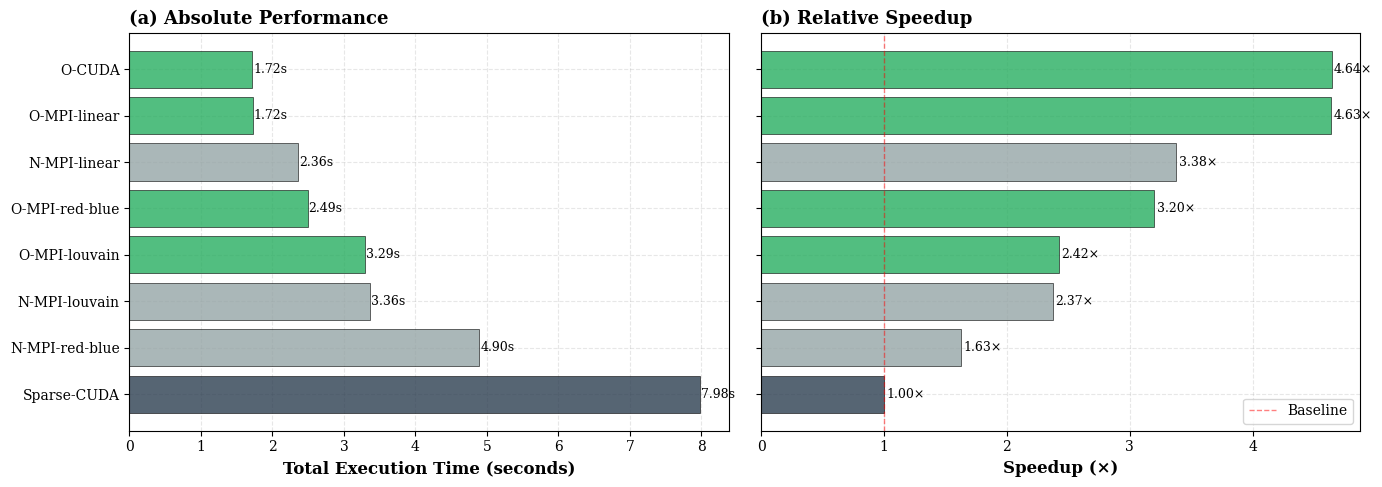

✓ Saved: performance_comparison.pdf/png


In [6]:
# Create performance comparison visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Prepare data
plot_df = perf_df.sort_values('total_execution_s', ascending=False).copy()
x_pos = np.arange(len(plot_df))

# Define colors based on variant
colors = [COLORS['optimized'] if 'optimized' in impl else 
          COLORS['naive'] if 'naive' in impl else '#2C3E50' 
          for impl in plot_df['implementation']]

# Panel 1: Absolute execution time
bars1 = ax1.barh(x_pos, plot_df['total_execution_s'], color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)
ax1.set_yticks(x_pos)
ax1.set_yticklabels(plot_df['implementation'].apply(
    lambda x: x.replace('naive-cuda-mpi-', 'N-MPI-')
             .replace('optimized-cuda-mpi-', 'O-MPI-')
             .replace('optimized-cuda', 'O-CUDA')
             .replace('sparse-cuda', 'Sparse-CUDA')
), fontsize=10)
ax1.set_xlabel('Total Execution Time (seconds)', fontweight='bold')
ax1.set_title('(a) Absolute Performance', loc='left')
ax1.grid(axis='x', alpha=0.3)

# Add value labels
for i, (bar, val) in enumerate(zip(bars1, plot_df['total_execution_s'])):
    ax1.text(val + 0.01, bar.get_y() + bar.get_height()/2, 
             f'{val:.2f}s', va='center', fontsize=9)

# Panel 2: Speedup relative to slowest
baseline = plot_df['total_execution_s'].max()
speedup = baseline / plot_df['total_execution_s']

bars2 = ax2.barh(x_pos, speedup, color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)
ax2.set_yticks(x_pos)
ax2.set_yticklabels([])  # Hide labels (same as left panel)
ax2.set_xlabel('Speedup (×)', fontweight='bold')
ax2.set_title('(b) Relative Speedup', loc='left')
ax2.axvline(x=1, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Baseline')
ax2.grid(axis='x', alpha=0.3)
ax2.legend()

# Add speedup labels
for i, (bar, val) in enumerate(zip(bars2, speedup)):
    ax2.text(val + 0.02, bar.get_y() + bar.get_height()/2, 
             f'{val:.2f}×', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'performance_comparison.pdf', bbox_inches='tight')
plt.savefig(OUTPUT_DIR / 'performance_comparison.png', bbox_inches='tight')
plt.show()

print(f"✓ Saved: performance_comparison.pdf/png")

## Visualization 2: Time Breakdown by Component

Show how time is distributed across CPU, GPU kernels, GPU memory, and MPI communication.

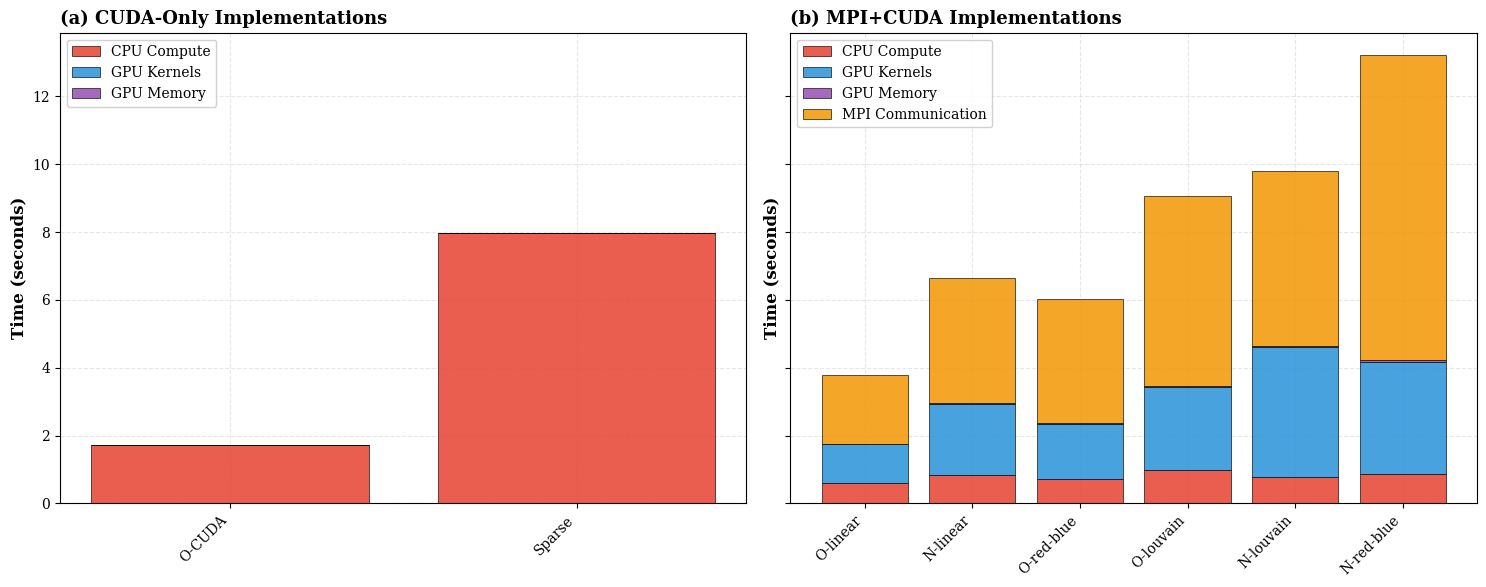

✓ Saved: time_breakdown.pdf/png


In [7]:
# Create stacked bar chart for time breakdown
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

# Separate CUDA-only and MPI implementations
cuda_df = perf_df[~perf_df['is_mpi']].sort_values('total_execution_s')
mpi_df = perf_df[perf_df['is_mpi']].sort_values('total_execution_s')

def plot_breakdown(ax, data, title):
    """Helper function to plot time breakdown."""
    if data.empty:
        return
    
    x_pos = np.arange(len(data))
    
    # Create stacked bars
    ax.bar(x_pos, data['cpu_compute_s'], label='CPU Compute', 
           color=COLORS['cpu'], alpha=0.9, edgecolor='black', linewidth=0.5)
    ax.bar(x_pos, data['cuda_kernel_s'], bottom=data['cpu_compute_s'],
           label='GPU Kernels', color=COLORS['gpu_kernel'], alpha=0.9, 
           edgecolor='black', linewidth=0.5)
    ax.bar(x_pos, data['cuda_memory_s'], 
           bottom=data['cpu_compute_s'] + data['cuda_kernel_s'],
           label='GPU Memory', color=COLORS['gpu_memory'], alpha=0.9, 
           edgecolor='black', linewidth=0.5)
    
    if 'mpi_s' in data.columns and data['mpi_s'].sum() > 0:
        ax.bar(x_pos, data['mpi_s'], 
               bottom=data['cpu_compute_s'] + data['cuda_kernel_s'] + data['cuda_memory_s'],
               label='MPI Communication', color=COLORS['mpi'], alpha=0.9, 
               edgecolor='black', linewidth=0.5)
    
    ax.set_xticks(x_pos)
    ax.set_xticklabels(data['implementation'].apply(
        lambda x: x.replace('naive-cuda-mpi-', 'N-')
                 .replace('optimized-cuda-mpi-', 'O-')
                 .replace('optimized-cuda', 'O-CUDA')
                 .replace('sparse-cuda', 'Sparse')
    ), rotation=45, ha='right', fontsize=10)
    ax.set_ylabel('Time (seconds)', fontweight='bold')
    ax.set_title(title, loc='left')
    ax.legend(loc='upper left', framealpha=0.9)
    ax.grid(axis='y', alpha=0.3)

# Plot both panels
plot_breakdown(ax1, cuda_df, '(a) CUDA-Only Implementations')
plot_breakdown(ax2, mpi_df, '(b) MPI+CUDA Implementations')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'time_breakdown.pdf', bbox_inches='tight')
plt.savefig(OUTPUT_DIR / 'time_breakdown.png', bbox_inches='tight')
plt.show()

print(f"✓ Saved: time_breakdown.pdf/png")

## Visualization 3: GPU Efficiency Analysis

Compare CPU vs GPU time and calculate GPU utilization.

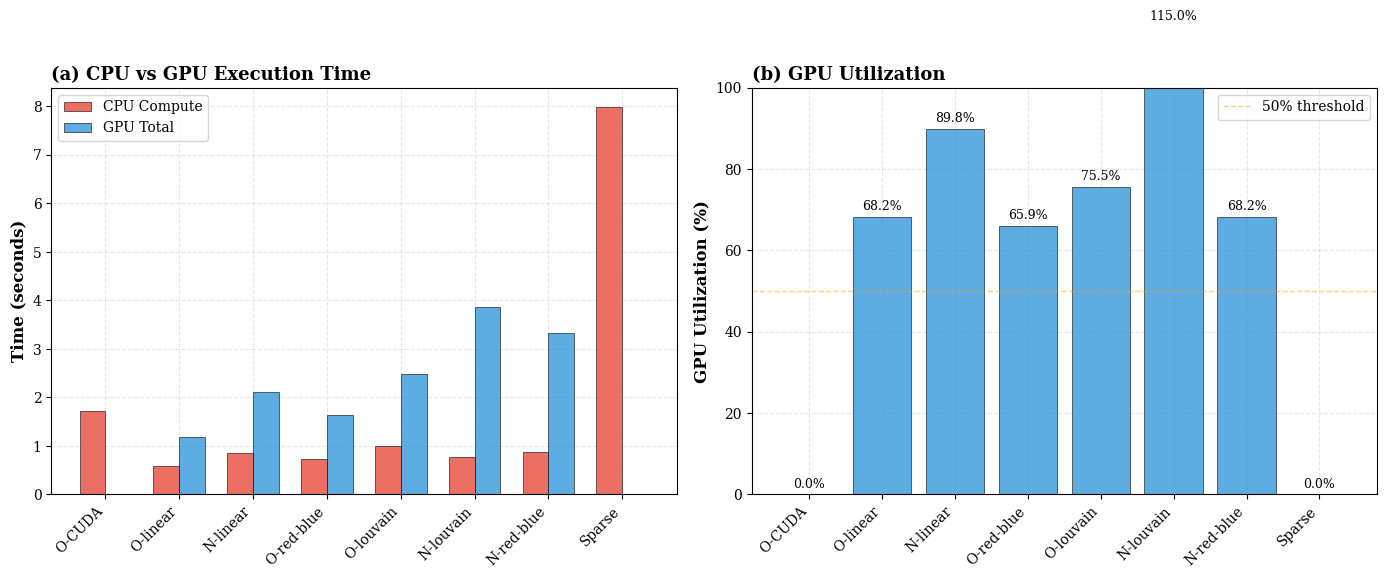

✓ Saved: gpu_efficiency.pdf/png


In [8]:
# Create GPU efficiency analysis
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Prepare data
plot_df = perf_df.sort_values('total_execution_s').copy()
plot_df['gpu_total_s'] = plot_df['cuda_kernel_s'] + plot_df['cuda_memory_s']
plot_df['gpu_utilization'] = (plot_df['gpu_total_s'] / plot_df['total_execution_s']) * 100

x_pos = np.arange(len(plot_df))
width = 0.35

# Panel 1: CPU vs GPU time (grouped bars)
bars1 = ax1.bar(x_pos - width/2, plot_df['cpu_compute_s'], width, 
                label='CPU Compute', color=COLORS['cpu'], alpha=0.8, 
                edgecolor='black', linewidth=0.5)
bars2 = ax1.bar(x_pos + width/2, plot_df['gpu_total_s'], width, 
                label='GPU Total', color=COLORS['gpu_kernel'], alpha=0.8, 
                edgecolor='black', linewidth=0.5)

ax1.set_xticks(x_pos)
ax1.set_xticklabels(plot_df['implementation'].apply(
    lambda x: x.replace('naive-cuda-mpi-', 'N-')
             .replace('optimized-cuda-mpi-', 'O-')
             .replace('optimized-cuda', 'O-CUDA')
             .replace('sparse-cuda', 'Sparse')
), rotation=45, ha='right', fontsize=10)
ax1.set_ylabel('Time (seconds)', fontweight='bold')
ax1.set_title('(a) CPU vs GPU Execution Time', loc='left')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Panel 2: GPU utilization percentage
bars3 = ax2.bar(x_pos, plot_df['gpu_utilization'], 
                color=COLORS['gpu_kernel'], alpha=0.8, 
                edgecolor='black', linewidth=0.5)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(plot_df['implementation'].apply(
    lambda x: x.replace('naive-cuda-mpi-', 'N-')
             .replace('optimized-cuda-mpi-', 'O-')
             .replace('optimized-cuda', 'O-CUDA')
             .replace('sparse-cuda', 'Sparse')
), rotation=45, ha='right', fontsize=10)
ax2.set_ylabel('GPU Utilization (%)', fontweight='bold')
ax2.set_title('(b) GPU Utilization', loc='left')
ax2.axhline(y=50, color='orange', linestyle='--', linewidth=1, alpha=0.5, label='50% threshold')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)
ax2.set_ylim(0, 100)

# Add percentage labels
for bar in bars3:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'gpu_efficiency.pdf', bbox_inches='tight')
plt.savefig(OUTPUT_DIR / 'gpu_efficiency.png', bbox_inches='tight')
plt.show()

print(f"✓ Saved: gpu_efficiency.pdf/png")

## Visualization 4: Load Balance Analysis for MPI Implementations

Analyze per-rank performance distribution and identify load imbalance.

Analyzing per-rank load balance...


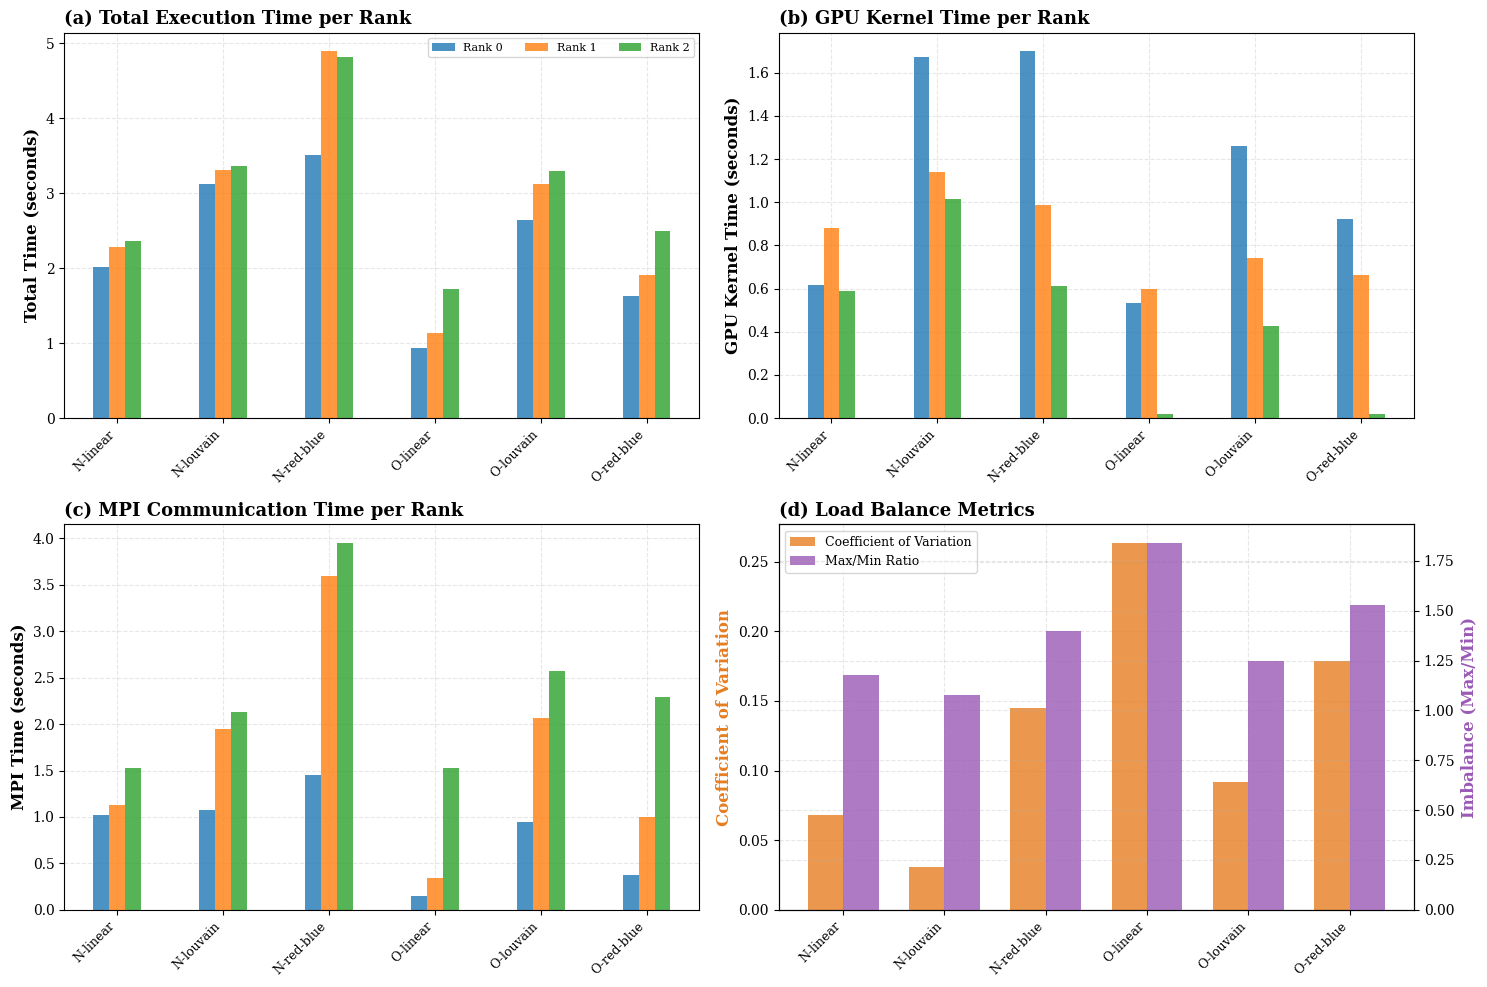

✓ Saved: load_balance_analysis.pdf/png


In [9]:
# Collect per-rank data for MPI implementations
print("Analyzing per-rank load balance...")

rank_data = []
for impl in MPI_IMPLS:
    num_ranks = get_num_ranks(impl)
    if num_ranks <= 1:
        continue
    
    for rank in range(num_ranks):
        breakdown = get_detailed_time_breakdown(impl, rank)
        if breakdown:
            rank_data.append({
                'implementation': impl,
                'rank': rank,
                'total_s': breakdown['total_execution_s'],
                'cuda_kernel_s': breakdown['cuda_kernel_s'],
                'mpi_s': breakdown['mpi_s'],
            })

rank_df = pd.DataFrame(rank_data)

if not rank_df.empty:
    # Calculate load balance metrics
    balance_metrics = []
    for impl in rank_df['implementation'].unique():
        impl_data = rank_df[rank_df['implementation'] == impl]
        total_times = impl_data['total_s'].values
        
        balance_metrics.append({
            'implementation': impl,
            'mean_time': total_times.mean(),
            'std_time': total_times.std(),
            'cv': total_times.std() / total_times.mean() if total_times.mean() > 0 else 0,
            'imbalance': total_times.max() / total_times.min() if total_times.min() > 0 else 0,
        })
    
    balance_df = pd.DataFrame(balance_metrics)
    
    # Create visualization
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))
    
    # Panel 1: Total execution time per rank
    implementations = rank_df['implementation'].unique()
    max_ranks = rank_df['rank'].max() + 1
    x_pos = np.arange(len(implementations))
    width = 0.15
    
    for rank in range(max_ranks):
        offsets = (rank - max_ranks/2 + 0.5) * width
        times = [rank_df[(rank_df['implementation'] == impl) & 
                        (rank_df['rank'] == rank)]['total_s'].values[0]
                if len(rank_df[(rank_df['implementation'] == impl) & 
                              (rank_df['rank'] == rank)]) > 0 else 0
                for impl in implementations]
        ax1.bar(x_pos + offsets, times, width, label=f'Rank {rank}', alpha=0.8)
    
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels([impl.replace('naive-cuda-mpi-', 'N-')
                        .replace('optimized-cuda-mpi-', 'O-')
                        for impl in implementations], rotation=45, ha='right', fontsize=9)
    ax1.set_ylabel('Total Time (seconds)', fontweight='bold')
    ax1.set_title('(a) Total Execution Time per Rank', loc='left')
    ax1.legend(ncol=4, fontsize=8)
    ax1.grid(axis='y', alpha=0.3)
    
    # Panel 2: GPU kernel time per rank
    for rank in range(max_ranks):
        offsets = (rank - max_ranks/2 + 0.5) * width
        times = [rank_df[(rank_df['implementation'] == impl) & 
                        (rank_df['rank'] == rank)]['cuda_kernel_s'].values[0]
                if len(rank_df[(rank_df['implementation'] == impl) & 
                              (rank_df['rank'] == rank)]) > 0 else 0
                for impl in implementations]
        ax2.bar(x_pos + offsets, times, width, alpha=0.8)
    
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels([impl.replace('naive-cuda-mpi-', 'N-')
                        .replace('optimized-cuda-mpi-', 'O-')
                        for impl in implementations], rotation=45, ha='right', fontsize=9)
    ax2.set_ylabel('GPU Kernel Time (seconds)', fontweight='bold')
    ax2.set_title('(b) GPU Kernel Time per Rank', loc='left')
    ax2.grid(axis='y', alpha=0.3)
    
    # Panel 3: MPI communication time per rank
    for rank in range(max_ranks):
        offsets = (rank - max_ranks/2 + 0.5) * width
        times = [rank_df[(rank_df['implementation'] == impl) & 
                        (rank_df['rank'] == rank)]['mpi_s'].values[0]
                if len(rank_df[(rank_df['implementation'] == impl) & 
                              (rank_df['rank'] == rank)]) > 0 else 0
                for impl in implementations]
        ax3.bar(x_pos + offsets, times, width, alpha=0.8)
    
    ax3.set_xticks(x_pos)
    ax3.set_xticklabels([impl.replace('naive-cuda-mpi-', 'N-')
                        .replace('optimized-cuda-mpi-', 'O-')
                        for impl in implementations], rotation=45, ha='right', fontsize=9)
    ax3.set_ylabel('MPI Time (seconds)', fontweight='bold')
    ax3.set_title('(c) MPI Communication Time per Rank', loc='left')
    ax3.grid(axis='y', alpha=0.3)
    
    # Panel 4: Load balance metrics
    x_pos_balance = np.arange(len(balance_df))
    width_metric = 0.35
    
    bars1 = ax4.bar(x_pos_balance - width_metric/2, balance_df['cv'], width_metric,
                   label='Coefficient of Variation', color='#E67E22', alpha=0.8)
    
    ax4_twin = ax4.twinx()
    bars2 = ax4_twin.bar(x_pos_balance + width_metric/2, balance_df['imbalance'], width_metric,
                        label='Max/Min Ratio', color='#9B59B6', alpha=0.8)
    
    ax4.set_xticks(x_pos_balance)
    ax4.set_xticklabels([impl.replace('naive-cuda-mpi-', 'N-')
                        .replace('optimized-cuda-mpi-', 'O-')
                        for impl in balance_df['implementation']], 
                       rotation=45, ha='right', fontsize=9)
    ax4.set_ylabel('Coefficient of Variation', fontweight='bold', color='#E67E22')
    ax4_twin.set_ylabel('Imbalance (Max/Min)', fontweight='bold', color='#9B59B6')
    ax4.set_title('(d) Load Balance Metrics', loc='left')
    ax4.grid(axis='y', alpha=0.3)
    
    # Combine legends
    lines1, labels1 = ax4.get_legend_handles_labels()
    lines2, labels2 = ax4_twin.get_legend_handles_labels()
    ax4.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'load_balance_analysis.pdf', bbox_inches='tight')
    plt.savefig(OUTPUT_DIR / 'load_balance_analysis.png', bbox_inches='tight')
    plt.show()
    
    print(f"✓ Saved: load_balance_analysis.pdf/png")
else:
    print("⚠ No multi-rank MPI data available")

## Visualization 5: Partitioning Strategy Comparison

Compare the effectiveness of different partitioning strategies (Linear, Louvain, Red-Blue).

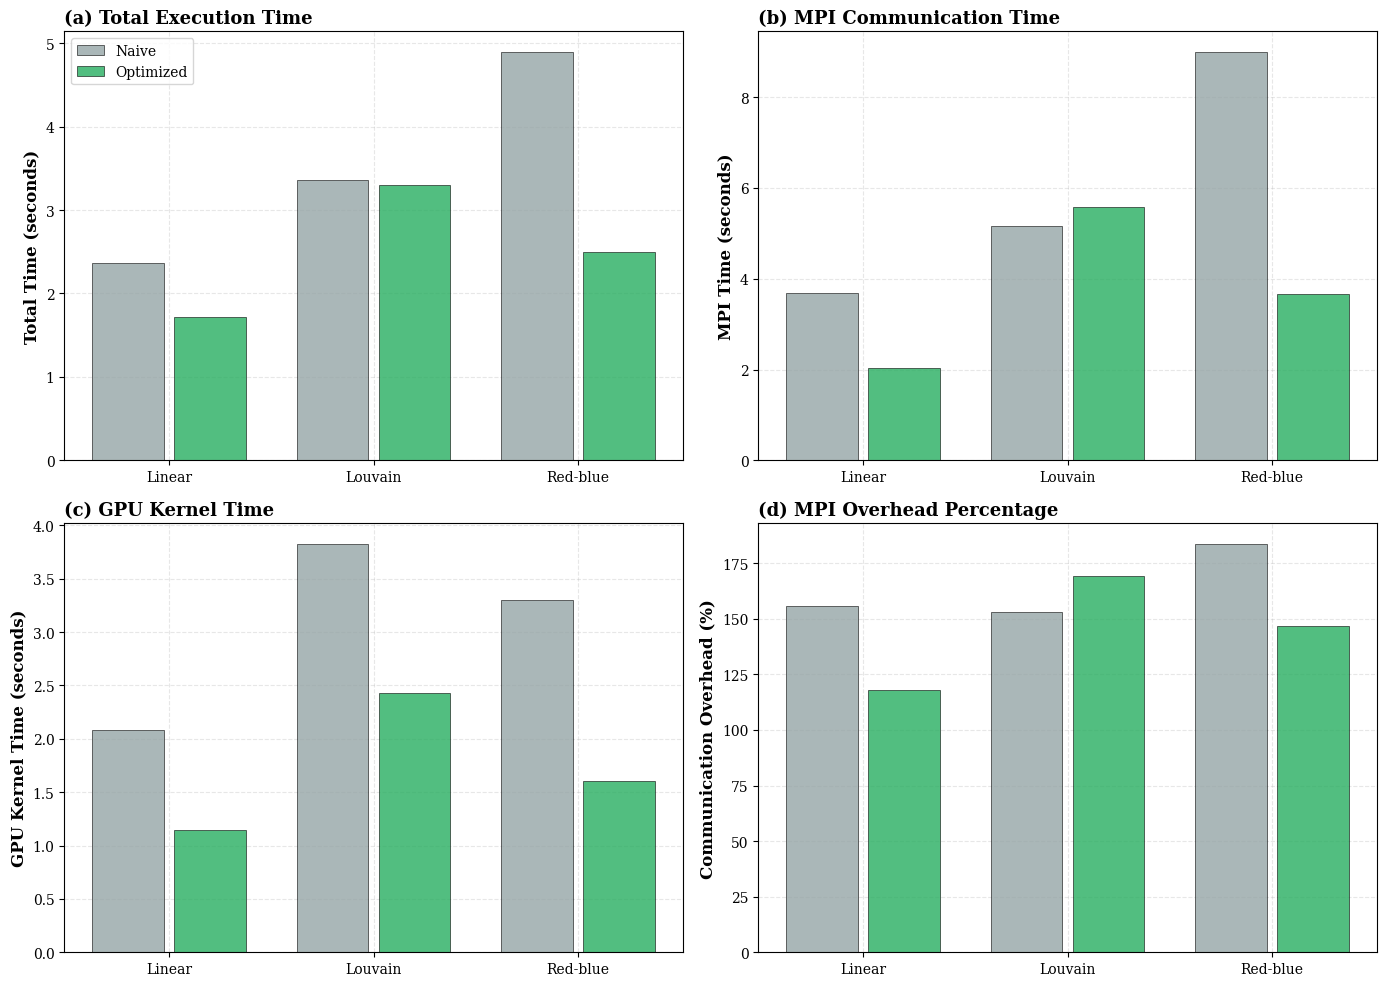

✓ Saved: partitioning_comparison.pdf/png


In [10]:
# Compare partitioning strategies
mpi_perf = perf_df[perf_df['is_mpi']].copy()

if not mpi_perf.empty:
    # Separate by variant (naive/optimized) and partitioning strategy
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))
    
    # Prepare data grouped by partitioning strategy
    strategies = ['linear', 'louvain', 'red-blue']
    variants = ['naive', 'optimized']
    
    # Panel 1: Total execution time by partitioning strategy
    for variant in variants:
        variant_data = mpi_perf[mpi_perf['variant'] == variant]
        times = [variant_data[variant_data['partitioning'] == s]['total_execution_s'].values[0]
                if len(variant_data[variant_data['partitioning'] == s]) > 0 else 0
                for s in strategies]
        
        x_offset = -0.2 if variant == 'naive' else 0.2
        colors_variant = COLORS['naive'] if variant == 'naive' else COLORS['optimized']
        ax1.bar(np.arange(len(strategies)) + x_offset, times, 0.35, 
               label=variant.capitalize(), color=colors_variant, alpha=0.8, 
               edgecolor='black', linewidth=0.5)
    
    ax1.set_xticks(range(len(strategies)))
    ax1.set_xticklabels([s.capitalize() for s in strategies])
    ax1.set_ylabel('Total Time (seconds)', fontweight='bold')
    ax1.set_title('(a) Total Execution Time', loc='left')
    ax1.legend()
    ax1.grid(axis='y', alpha=0.3)
    
    # Panel 2: MPI communication time
    for variant in variants:
        variant_data = mpi_perf[mpi_perf['variant'] == variant]
        times = [variant_data[variant_data['partitioning'] == s]['mpi_s'].values[0]
                if len(variant_data[variant_data['partitioning'] == s]) > 0 else 0
                for s in strategies]
        
        x_offset = -0.2 if variant == 'naive' else 0.2
        colors_variant = COLORS['naive'] if variant == 'naive' else COLORS['optimized']
        ax2.bar(np.arange(len(strategies)) + x_offset, times, 0.35, 
               color=colors_variant, alpha=0.8, edgecolor='black', linewidth=0.5)
    
    ax2.set_xticks(range(len(strategies)))
    ax2.set_xticklabels([s.capitalize() for s in strategies])
    ax2.set_ylabel('MPI Time (seconds)', fontweight='bold')
    ax2.set_title('(b) MPI Communication Time', loc='left')
    ax2.grid(axis='y', alpha=0.3)
    
    # Panel 3: GPU kernel time
    for variant in variants:
        variant_data = mpi_perf[mpi_perf['variant'] == variant]
        times = [variant_data[variant_data['partitioning'] == s]['cuda_kernel_s'].values[0]
                if len(variant_data[variant_data['partitioning'] == s]) > 0 else 0
                for s in strategies]
        
        x_offset = -0.2 if variant == 'naive' else 0.2
        colors_variant = COLORS['naive'] if variant == 'naive' else COLORS['optimized']
        ax3.bar(np.arange(len(strategies)) + x_offset, times, 0.35, 
               color=colors_variant, alpha=0.8, edgecolor='black', linewidth=0.5)
    
    ax3.set_xticks(range(len(strategies)))
    ax3.set_xticklabels([s.capitalize() for s in strategies])
    ax3.set_ylabel('GPU Kernel Time (seconds)', fontweight='bold')
    ax3.set_title('(c) GPU Kernel Time', loc='left')
    ax3.grid(axis='y', alpha=0.3)
    
    # Panel 4: Communication overhead percentage
    for variant in variants:
        variant_data = mpi_perf[mpi_perf['variant'] == variant]
        overhead = []
        for s in strategies:
            s_data = variant_data[variant_data['partitioning'] == s]
            if len(s_data) > 0:
                total = s_data['total_execution_s'].values[0]
                mpi = s_data['mpi_s'].values[0]
                overhead.append((mpi / total * 100) if total > 0 else 0)
            else:
                overhead.append(0)
        
        x_offset = -0.2 if variant == 'naive' else 0.2
        colors_variant = COLORS['naive'] if variant == 'naive' else COLORS['optimized']
        ax4.bar(np.arange(len(strategies)) + x_offset, overhead, 0.35, 
               color=colors_variant, alpha=0.8, edgecolor='black', linewidth=0.5)
    
    ax4.set_xticks(range(len(strategies)))
    ax4.set_xticklabels([s.capitalize() for s in strategies])
    ax4.set_ylabel('Communication Overhead (%)', fontweight='bold')
    ax4.set_title('(d) MPI Overhead Percentage', loc='left')
    ax4.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'partitioning_comparison.pdf', bbox_inches='tight')
    plt.savefig(OUTPUT_DIR / 'partitioning_comparison.png', bbox_inches='tight')
    plt.show()
    
    print(f"✓ Saved: partitioning_comparison.pdf/png")
else:
    print("⚠ No MPI implementation data available")

## Visualization 6: CUDA Kernel Performance Breakdown

Analyze which CUDA kernels dominate execution time.

Analyzing CUDA kernel breakdown...


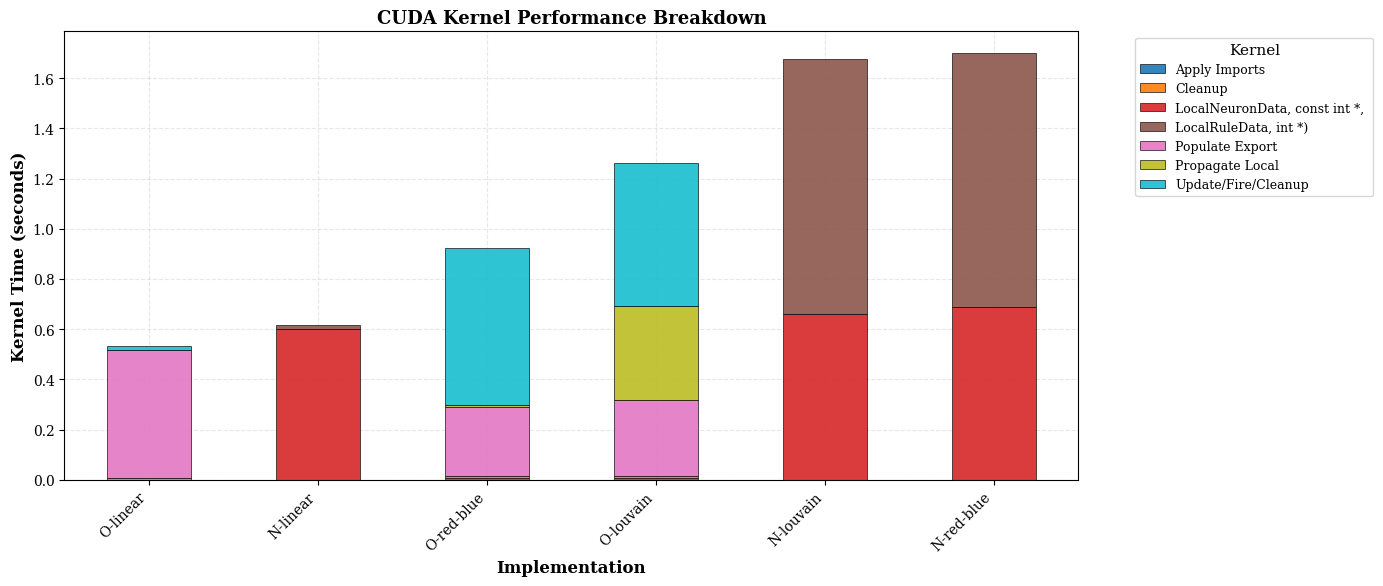

✓ Saved: kernel_breakdown.pdf/png


In [11]:
# Analyze CUDA kernel performance
print("Analyzing CUDA kernel breakdown...")

kernel_data = []
for impl in ALL_IMPLS:
    # Load kernel data (from rank 0 for MPI implementations)
    kernel_df = load_csv_safely(impl, "stats_cuda_gpu_kern_sum.csv", rank=0)
    
    if kernel_df is not None:
        for _, row in kernel_df.iterrows():
            kernel_name = row['Name']
            # Simplify kernel names
            if 'kUpdateSelectFireCleanup' in kernel_name:
                simple_name = 'Update/Fire/Cleanup'
            elif 'kPopulateExport' in kernel_name:
                simple_name = 'Populate Export'
            elif 'kPropagateLocal' in kernel_name:
                simple_name = 'Propagate Local'
            elif 'kApplyImports' in kernel_name:
                simple_name = 'Apply Imports'
            elif 'kCleanupAfterPropagation' in kernel_name:
                simple_name = 'Cleanup'
            else:
                simple_name = kernel_name.split('::')[-1][:30]
            
            kernel_data.append({
                'implementation': impl,
                'kernel': simple_name,
                'time_s': row['Total Time (ns)'] / 1e9,
                'percentage': row['Time (%)'],
            })

kernel_analysis = pd.DataFrame(kernel_data)

if not kernel_analysis.empty:
    # Create stacked bar chart
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # Pivot data for stacking
    pivot_data = kernel_analysis.pivot_table(
        index='implementation', 
        columns='kernel', 
        values='time_s', 
        fill_value=0
    )
    
    # Sort implementations
    impl_order = perf_df.sort_values('total_execution_s')['implementation'].tolist()
    pivot_data = pivot_data.reindex([impl for impl in impl_order if impl in pivot_data.index])
    
    # Plot stacked bars
    pivot_data.plot(kind='bar', stacked=True, ax=ax, colormap='tab10', 
                   alpha=0.9, edgecolor='black', linewidth=0.5)
    
    ax.set_xlabel('Implementation', fontweight='bold')
    ax.set_ylabel('Kernel Time (seconds)', fontweight='bold')
    ax.set_title('CUDA Kernel Performance Breakdown', fontweight='bold')
    ax.set_xticklabels([impl.replace('naive-cuda-mpi-', 'N-')
                       .replace('optimized-cuda-mpi-', 'O-')
                       .replace('optimized-cuda', 'O-CUDA')
                       .replace('sparse-cuda', 'Sparse')
                       for impl in pivot_data.index], 
                      rotation=45, ha='right', fontsize=10)
    ax.legend(title='Kernel', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'kernel_breakdown.pdf', bbox_inches='tight')
    plt.savefig(OUTPUT_DIR / 'kernel_breakdown.png', bbox_inches='tight')
    plt.show()
    
    print(f"✓ Saved: kernel_breakdown.pdf/png")
else:
    print("⚠ No kernel data available")

## Statistical Summary Tables

Generate LaTeX-formatted tables for paper inclusion.

In [12]:
# Generate comprehensive summary table
print("Generating statistical summary tables...\n")

# Table 1: Overall performance metrics
summary_table = perf_df[[
    'implementation', 'total_execution_s', 'cpu_compute_s', 
    'cuda_kernel_s', 'cuda_memory_s', 'mpi_s'
]].copy()

summary_table.columns = ['Implementation', 'Total (s)', 'CPU (s)', 
                        'GPU Kernel (s)', 'GPU Memory (s)', 'MPI (s)']

# Calculate percentages
for col in ['CPU (s)', 'GPU Kernel (s)', 'GPU Memory (s)', 'MPI (s)']:
    pct_col = col.replace(' (s)', ' (%)')
    summary_table[pct_col] = (summary_table[col] / summary_table['Total (s)'] * 100).round(1)

# Sort by total time
summary_table = summary_table.sort_values('Total (s)')

# Format for display
display_table = summary_table.copy()
for col in display_table.columns:
    if '(s)' in col:
        display_table[col] = display_table[col].apply(lambda x: f'{x:.3f}')
    elif '(%)' in col:
        display_table[col] = display_table[col].apply(lambda x: f'{x:.1f}')

print("Performance Summary Table:")
print("="*100)
print(display_table.to_string(index=False))
print()

# Generate LaTeX table
latex_columns = ['Implementation', 'Total (s)', 'CPU (%)', 'GPU Kernel (%)', 
                'GPU Memory (%)', 'MPI (%)']
latex_table = summary_table[latex_columns].copy()

# Shorten implementation names for LaTeX
latex_table['Implementation'] = latex_table['Implementation'].apply(
    lambda x: x.replace('naive-cuda-mpi-', 'N-MPI-')
             .replace('optimized-cuda-mpi-', 'O-MPI-')
             .replace('optimized-cuda', 'O-CUDA')
             .replace('sparse-cuda', 'Sparse')
)

# Format numbers
latex_table['Total (s)'] = latex_table['Total (s)'].apply(lambda x: f'{x:.2f}')
for col in ['CPU (%)', 'GPU Kernel (%)', 'GPU Memory (%)', 'MPI (%)']:
    latex_table[col] = latex_table[col].apply(lambda x: f'{x:.1f}')

# Convert to LaTeX
latex_output = latex_table.to_latex(index=False, escape=False, column_format='l|r|rrrr')

# Save LaTeX table
latex_path = OUTPUT_DIR / 'performance_summary.tex'
with open(latex_path, 'w') as f:
    f.write("% Performance Summary Table\n")
    f.write("% Generated by nsys_analysis_2.ipynb\n\n")
    f.write(latex_output)

print(f"✓ LaTeX table saved to: {latex_path}")
print()
print("LaTeX Table Preview:")
print("-"*80)
print(latex_output)

Generating statistical summary tables...

Performance Summary Table:
             Implementation Total (s) CPU (s) GPU Kernel (s) GPU Memory (s) MPI (s) CPU (%) GPU Kernel (%) GPU Memory (%) MPI (%)
             optimized-cuda     1.720   1.720          0.000          0.000   0.000   100.0            0.0            0.0     0.0
  optimized-cuda-mpi-linear     1.722   0.591          1.149          0.025   2.031    34.3           66.7            1.5   117.9
      naive-cuda-mpi-linear     2.363   0.848          2.085          0.037   3.677    35.9           88.3            1.5   155.6
optimized-cuda-mpi-red-blue     2.495   0.733          1.608          0.037   3.660    29.4           64.5            1.5   146.7
 optimized-cuda-mpi-louvain     3.294   0.989          2.432          0.056   5.581    30.0           73.8            1.7   169.4
     naive-cuda-mpi-louvain     3.363   0.782          3.828          0.039   5.153    23.2          113.8            1.2   153.2
    naive-cuda-mpi-re

In [13]:
# Table 2: Load balance metrics for MPI implementations
if not rank_df.empty:
    print("\nLoad Balance Analysis Table:")
    print("="*100)
    
    balance_summary = []
    for impl in MPI_IMPLS:
        impl_ranks = rank_df[rank_df['implementation'] == impl]
        if impl_ranks.empty:
            continue
        
        total_times = impl_ranks['total_s'].values
        gpu_times = impl_ranks['cuda_kernel_s'].values
        mpi_times = impl_ranks['mpi_s'].values
        
        balance_summary.append({
            'Implementation': impl,
            'Num Ranks': len(impl_ranks),
            'Mean Time (s)': total_times.mean(),
            'Std Dev (s)': total_times.std(),
            'CV': total_times.std() / total_times.mean() if total_times.mean() > 0 else 0,
            'Imbalance': total_times.max() / total_times.min() if total_times.min() > 0 else 0,
            'GPU Imbalance': gpu_times.max() / gpu_times.min() if gpu_times.min() > 0 else 0,
            'MPI Imbalance': mpi_times.max() / mpi_times.min() if mpi_times.min() > 0 else 0,
        })
    
    balance_table = pd.DataFrame(balance_summary)
    
    # Format for display
    display_balance = balance_table.copy()
    display_balance['Mean Time (s)'] = display_balance['Mean Time (s)'].apply(lambda x: f'{x:.3f}')
    display_balance['Std Dev (s)'] = display_balance['Std Dev (s)'].apply(lambda x: f'{x:.3f}')
    display_balance['CV'] = display_balance['CV'].apply(lambda x: f'{x:.3f}')
    display_balance['Imbalance'] = display_balance['Imbalance'].apply(lambda x: f'{x:.2f}')
    display_balance['GPU Imbalance'] = display_balance['GPU Imbalance'].apply(lambda x: f'{x:.2f}')
    display_balance['MPI Imbalance'] = display_balance['MPI Imbalance'].apply(lambda x: f'{x:.2f}')
    
    print(display_balance.to_string(index=False))
    print()
    
    # Generate LaTeX table
    latex_balance = balance_table.copy()
    latex_balance['Implementation'] = latex_balance['Implementation'].apply(
        lambda x: x.replace('naive-cuda-mpi-', 'N-')
                 .replace('optimized-cuda-mpi-', 'O-')
    )
    
    latex_balance['Mean Time (s)'] = latex_balance['Mean Time (s)'].apply(lambda x: f'{x:.2f}')
    latex_balance['Std Dev (s)'] = latex_balance['Std Dev (s)'].apply(lambda x: f'{x:.3f}')
    latex_balance['CV'] = latex_balance['CV'].apply(lambda x: f'{x:.3f}')
    latex_balance['Imbalance'] = latex_balance['Imbalance'].apply(lambda x: f'{x:.2f}')
    
    latex_balance_output = latex_balance[['Implementation', 'Num Ranks', 'Mean Time (s)', 
                                         'CV', 'Imbalance']].to_latex(
        index=False, escape=False, column_format='l|r|r|r|r'
    )
    
    # Save LaTeX table
    latex_balance_path = OUTPUT_DIR / 'load_balance_summary.tex'
    with open(latex_balance_path, 'w') as f:
        f.write("% Load Balance Summary Table\n")
        f.write("% Generated by nsys_analysis_2.ipynb\n\n")
        f.write(latex_balance_output)
    
    print(f"✓ LaTeX table saved to: {latex_balance_path}")
    print()
    print("LaTeX Table Preview:")
    print("-"*80)
    print(latex_balance_output)


Load Balance Analysis Table:
             Implementation  Num Ranks Mean Time (s) Std Dev (s)    CV Imbalance GPU Imbalance MPI Imbalance
      naive-cuda-mpi-linear          3         2.215       0.151 0.068      1.18          1.50          1.50
     naive-cuda-mpi-louvain          3         3.267       0.101 0.031      1.08          1.65          1.99
    naive-cuda-mpi-red-blue          3         4.407       0.637 0.145      1.40          2.78          2.72
  optimized-cuda-mpi-linear          3         1.265       0.334 0.264      1.84         28.98         10.05
 optimized-cuda-mpi-louvain          3         3.019       0.276 0.092      1.25          2.96          2.73
optimized-cuda-mpi-red-blue          3         2.013       0.360 0.179      1.53         44.85          6.09

✓ LaTeX table saved to: results/nsys/20260104_184616/figures/load_balance_summary.tex

LaTeX Table Preview:
--------------------------------------------------------------------------------
\begin{tabular}{l

## Summary and Conclusions

Key findings from the profiling analysis.

In [14]:
# Generate summary statistics and key findings
print("="*80)
print("PROFILING ANALYSIS SUMMARY")
print("="*80)
print()

# Best performer
best_impl = perf_df.loc[perf_df['total_execution_s'].idxmin()]
print(f"✓ Fastest Implementation: {best_impl['implementation']}")
print(f"  Execution Time: {best_impl['total_execution_s']:.3f} seconds")
print()

# Speedup analysis
if not perf_df.empty:
    baseline = perf_df['total_execution_s'].max()
    fastest = perf_df['total_execution_s'].min()
    print(f"✓ Maximum Speedup: {baseline/fastest:.2f}× (vs slowest implementation)")
    print()

# GPU utilization
avg_gpu_util = ((perf_df['cuda_kernel_s'] + perf_df['cuda_memory_s']) / 
                perf_df['total_execution_s'] * 100).mean()
print(f"✓ Average GPU Utilization: {avg_gpu_util:.1f}%")
print()

# MPI overhead
if not mpi_perf.empty:
    avg_mpi_overhead = (mpi_perf['mpi_s'] / mpi_perf['total_execution_s'] * 100).mean()
    print(f"✓ Average MPI Communication Overhead: {avg_mpi_overhead:.1f}%")
    print()

# Best partitioning strategy
if not rank_df.empty and not balance_df.empty:
    best_partition = balance_df.loc[balance_df['cv'].idxmin()]
    print(f"✓ Best Load Balance: {best_partition['implementation']}")
    print(f"  Coefficient of Variation: {best_partition['cv']:.3f}")
    print(f"  Imbalance Ratio: {best_partition['imbalance']:.2f}")
    print()

# Kernel analysis
if not kernel_analysis.empty:
    # Find most time-consuming kernel across all implementations
    total_by_kernel = kernel_analysis.groupby('kernel')['time_s'].sum().sort_values(ascending=False)
    print(f"✓ Most Time-Consuming Kernels:")
    for i, (kernel, time) in enumerate(total_by_kernel.head(3).items(), 1):
        pct = (time / kernel_analysis['time_s'].sum()) * 100
        print(f"  {i}. {kernel}: {time:.3f}s ({pct:.1f}% of total kernel time)")
    print()

print("="*80)
print(f"All visualizations saved to: {OUTPUT_DIR}")
print("="*80)
print()
print("Generated Files:")
print("  • performance_comparison.pdf/png")
print("  • time_breakdown.pdf/png")
print("  • gpu_efficiency.pdf/png")
print("  • load_balance_analysis.pdf/png (if MPI data available)")
print("  • partitioning_comparison.pdf/png (if MPI data available)")
print("  • kernel_breakdown.pdf/png")
print("  • performance_summary.tex")
print("  • load_balance_summary.tex (if MPI data available)")

PROFILING ANALYSIS SUMMARY

✓ Fastest Implementation: optimized-cuda
  Execution Time: 1.720 seconds

✓ Maximum Speedup: 4.64× (vs slowest implementation)

✓ Average GPU Utilization: 60.3%

✓ Average MPI Communication Overhead: 154.5%

✓ Best Load Balance: naive-cuda-mpi-louvain
  Coefficient of Variation: 0.031
  Imbalance Ratio: 1.08

✓ Most Time-Consuming Kernels:
  1. LocalRuleData, int *): 2.042s (30.4% of total kernel time)
  2. LocalNeuronData, const int *, : 1.950s (29.1% of total kernel time)
  3. Update/Fire/Cleanup: 1.209s (18.0% of total kernel time)

All visualizations saved to: results/nsys/20260104_184616/figures

Generated Files:
  • performance_comparison.pdf/png
  • time_breakdown.pdf/png
  • gpu_efficiency.pdf/png
  • load_balance_analysis.pdf/png (if MPI data available)
  • partitioning_comparison.pdf/png (if MPI data available)
  • kernel_breakdown.pdf/png
  • performance_summary.tex
  • load_balance_summary.tex (if MPI data available)
